# Customer Profile and Group Comparability

## Business Question

Who are Vanguard's customers, and are the Test and Control groups comparable?

## Objective

The purpose of this analysis is to understand the characteristics of clients included in Vanguard's A/B experiment and determine whether the Test and Control groups are reasonably comparable.

Before evaluating whether the redesigned digital experience performed better, we need to check whether differences between the groups already existed in client characteristics such as age, tenure, account balance, number of accounts, calls, logons, and gender.

This analysis focuses on client-level characteristics because `client_id` is the experimental unit.

In [4]:
import pandas as pd
import os

print(os.getcwd())

/Users/jannoelvero/Documents/Ironhack/week_6/Week_6_Project


In [5]:
import pandas as pd

demo_df = pd.read_csv(
    "data/raw/df_final_demo.txt"
)

experiment_df = pd.read_csv(
    "data/raw/df_final_experiment_clients (1).txt"
)

In [6]:
print("Client Profiles:", demo_df.shape)
print("Experiment Roster:", experiment_df.shape)

Client Profiles: (70609, 9)
Experiment Roster: (70609, 2)


In [7]:
clients_df = demo_df.merge(
    experiment_df,
    on="client_id",
    how="inner"
)

print("Merged clients:", clients_df.shape)

Merged clients: (70609, 10)


In [9]:
ab_clients_df = clients_df[
    clients_df["Variation"].isin(["Test", "Control"])
].copy()

print("A/B experiment clients:", ab_clients_df.shape)

A/B experiment clients: (50500, 10)


In [12]:
#Group size verification
ab_clients_df["Variation"].value_counts()

Variation
Test       26968
Control    23532
Name: count, dtype: int64

In [11]:
ab_clients_df["Variation"].value_counts(
    normalize=True
) * 100

Variation
Test       53.40198
Control    46.59802
Name: proportion, dtype: float64

### Who are Vanguard's experimental customers?
Describe Vanguard's overall profile of clients participating in the experiment before separating Test and Control.

In [14]:
ab_clients_df[
    [
        "clnt_age",
        "clnt_tenure_yr",
        "clnt_tenure_mnth",
        "num_accts",
        "bal",
        "calls_6_mnth",
        "logons_6_mnth"
    ]
].describe()

,clnt_age,clnt_tenure_yr,clnt_tenure_mnth,num_accts,bal,calls_6_mnth,logons_6_mnth
count,50487.000000,50488.000000,50488.000000,50488.000000,5.048800e+04,50488.000000,50488.000000
mean,47.319795,12.031730,150.415485,2.254575,1.495147e+05,3.093289,6.131873
std,15.518616,6.860282,81.944830,0.533671,3.020364e+05,2.187991,2.175423
min,17.000000,2.000000,33.000000,1.000000,2.378944e+04,0.000000,3.000000
25%,33.500000,6.000000,82.000000,2.000000,3.987841e+04,1.000000,4.000000
50%,48.000000,11.000000,136.000000,2.000000,6.573360e+04,3.000000,6.000000
75%,59.500000,16.000000,192.000000,2.000000,1.399565e+05,5.000000,8.000000
max,96.000000,55.000000,669.000000,7.000000,1.632004e+07,6.000000,9.000000


In [15]:
#check gender
ab_clients_df["gendr"].value_counts(
    dropna=False
)

gendr
U      17280
M      16947
F      16259
NaN       12
X          2
Name: count, dtype: int64

In [16]:
ab_clients_df["gendr"].value_counts(
    dropna=False,
    normalize=True
) * 100

gendr
U      34.217822
M      33.558416
F      32.196040
NaN     0.023762
X       0.003960
Name: proportion, dtype: float64

In [19]:
#check missing values in the A/B population
ab_clients_df.isnull().sum()

client_id            0
clnt_tenure_yr      12
clnt_tenure_mnth    12
clnt_age            13
gendr               12
num_accts           12
bal                 12
calls_6_mnth        12
logons_6_mnth       12
Variation            0
dtype: int64

### Missing Values in the Experimental Population

The A/B experiment dataset contains very limited missing demographic information. Most client characteristics contain 12 missing observations, while `clnt_age` contains 13 missing observations among 50,500 experimental clients.

No experimental assignments are missing because the dataset has already been restricted to Test and Control participants.

Given the extremely small proportion of missing values, no imputation will be performed. Analyses requiring these variables will use the available observations, and missing records will be excluded only where necessary for the specific calculation or statistical test.

In [21]:
ab_clients_df[
    [
        "clnt_age",
        "clnt_tenure_yr",
        "clnt_tenure_mnth",
        "num_accts",
        "bal",
        "calls_6_mnth",
        "logons_6_mnth"
    ]
].describe()

,clnt_age,clnt_tenure_yr,clnt_tenure_mnth,num_accts,bal,calls_6_mnth,logons_6_mnth
count,50487.000000,50488.000000,50488.000000,50488.000000,5.048800e+04,50488.000000,50488.000000
mean,47.319795,12.031730,150.415485,2.254575,1.495147e+05,3.093289,6.131873
std,15.518616,6.860282,81.944830,0.533671,3.020364e+05,2.187991,2.175423
min,17.000000,2.000000,33.000000,1.000000,2.378944e+04,0.000000,3.000000
25%,33.500000,6.000000,82.000000,2.000000,3.987841e+04,1.000000,4.000000
50%,48.000000,11.000000,136.000000,2.000000,6.573360e+04,3.000000,6.000000
75%,59.500000,16.000000,192.000000,2.000000,1.399565e+05,5.000000,8.000000
max,96.000000,55.000000,669.000000,7.000000,1.632004e+07,6.000000,9.000000


In [22]:
ab_clients_df["gendr"].value_counts(
    dropna=False
)

gendr
U      17280
M      16947
F      16259
NaN       12
X          2
Name: count, dtype: int64

In [23]:
ab_clients_df["gendr"].value_counts(
    dropna=False,
    normalize=True
) * 100

gendr
U      34.217822
M      33.558416
F      32.196040
NaN     0.023762
X       0.003960
Name: proportion, dtype: float64

## Vanguard Experimental Customer Profile

The A/B experiment contains 50,500 clients with known Test or Control assignments.

The average client age is approximately 47.3 years, with a median age of 48 years. The middle 50% of clients are approximately 33.5 to 59.5 years old.

Clients have an average tenure of approximately 12 years with Vanguard, while the median tenure is 11 years. This indicates that many participants are# established Vanguard clients rather than exclusively new customers.

Clients hold an average of approximately 2.25 accounts, with a median of 2 accounts.

Account balances are strongly right skewed. The median client balance is approximately $65,734, while the mean is approximately $149,515. The substantial difference between the mean and median is influenced by high balance clients, including balances exceeding $16 million. Therefore, both median and distributional measures should be considered when interpreting client balances.

Clients recorded an average of approximately 3.1 calls and 6.1 logons during the previous six months.

The major recorded gender categories are relatively evenly distributed. `U` represents approximately 34.22%, `M` 33.56%, and `F` 32.20% of experimental clients. The supplied metadata does not define the meaning of `U` or `X`, so the original categories will be preserved rather than recoded based on assumptions.

### Test and Control 
Compare the baseline characteristics of Test and Control before analyzing experimental outcomes.

In [25]:

numeric_columns = [
    "clnt_age",
    "clnt_tenure_yr",
    "clnt_tenure_mnth",
    "num_accts",
    "bal",
    "calls_6_mnth",
    "logons_6_mnth"
]

group_summary = (
    ab_clients_df
    .groupby("Variation")[numeric_columns]
    .agg(["mean", "median"])
)

group_summary

clnt_age        clnt_tenure_yr        clnt_tenure_mnth         \
                mean median           mean median             mean median   
Variation                                                                   
Control    47.498427   48.5      12.087686   11.0       151.060186  137.0   
Test       47.163922   47.5      11.982901   11.0       149.852899  134.0   

          num_accts                   bal           calls_6_mnth         \
               mean median           mean    median         mean median   
Variation                                                                 
Control    2.259914    2.0  150147.326660  66024.18     3.129213    3.0   
Test       2.249917    2.0  148962.605032  65468.36     3.061941    3.0   

          logons_6_mnth         
                   mean median  
Variation                       
Control        6.166277    6.0  
Test           6.101851    6.0

In [26]:
#compare gender by group
gender_comparison = pd.crosstab(
    ab_clients_df["gendr"],
    ab_clients_df["Variation"],
    normalize="columns"
) * 100

gender_comparison

Variation,Control,Test
gendr,,
F,32.061036,32.328178
M,33.875972,33.296243
U,34.062991,34.368161
X,0.000000,0.007418


### Preliminary Test and Control Comparison

The descriptive statistics indicate that the Test and Control groups are broadly similar across the observed baseline client characteristics.

Average age, tenure, number of accounts, account balance, calls, and logons show only small differences between the two groups. Median values are also very similar, with identical medians for tenure, number of accounts, calls, and logons.

The recorded gender distributions are also similar between Test and Control.

These descriptive results provide preliminary evidence that the experimental groups are reasonably balanced. However, descriptive similarity alone is not sufficient to establish comparability. Distributional differences, outliers, and appropriate statistical tests will therefore be examined before reaching a final conclusion about baseline balance.

## Visual comparison

In [28]:

#visualize before hypothesis testing.
import matplotlib.pyplot as plt
import seaborn as sns

Age: Compare the age distributions of Test and Control and look for differences in shape, center, spread, and possible outliers.

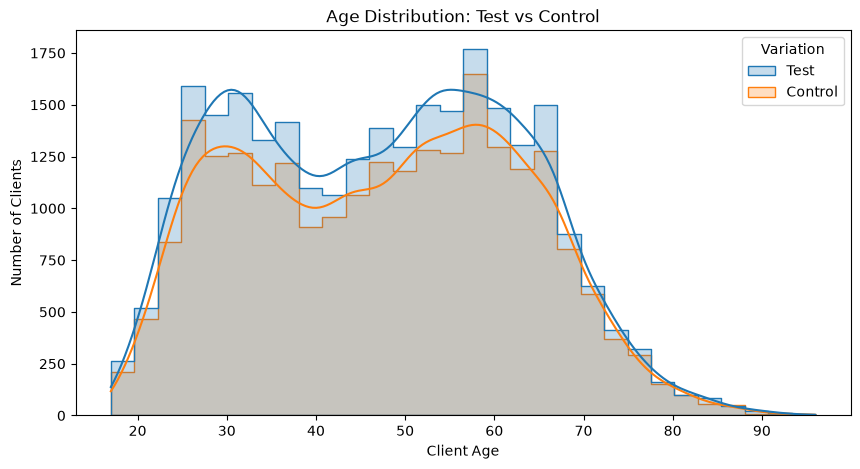

In [30]:
#Histogram
plt.figure(figsize=(10, 5))

sns.histplot(
    data=ab_clients_df,
    x="clnt_age",
    hue="Variation",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Age Distribution: Test vs Control")
plt.xlabel("Client Age")
plt.ylabel("Number of Clients")

plt.show()

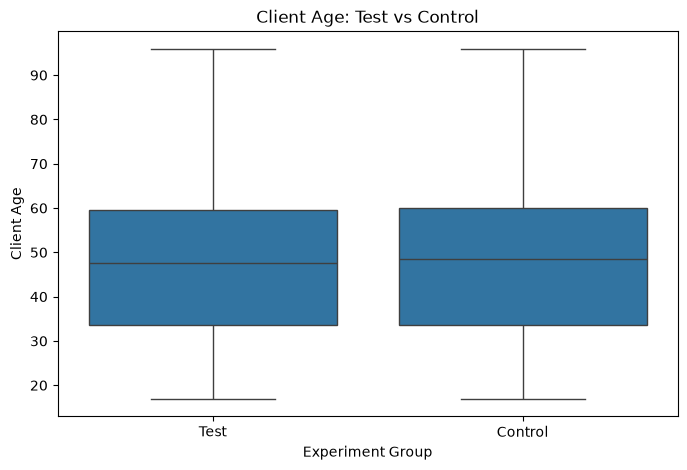

In [31]:
#Boxplot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=ab_clients_df,
    x="Variation",
    y="clnt_age"
)

plt.title("Client Age: Test vs Control")
plt.xlabel("Experiment Group")
plt.ylabel("Client Age")

plt.show()

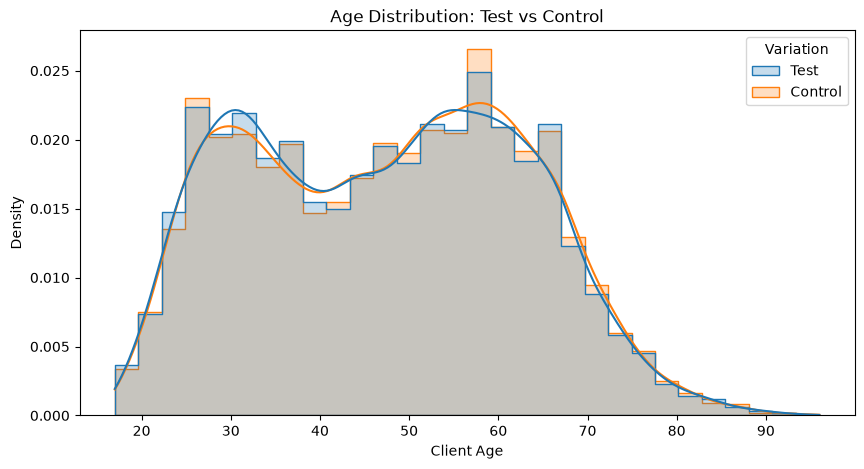

In [32]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=ab_clients_df,
    x="clnt_age",
    hue="Variation",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Age Distribution: Test vs Control")
plt.xlabel("Client Age")
plt.ylabel("Density")

plt.show()

### Age Distribution: Test vs Control

The age distributions of the Test and Control groups show substantial overlap.

The Test group has a mean age of approximately 47.16 years and a median age of 47.5 years, compared with a mean of approximately 47.50 years and a median of 48.5 years for the Control group.

The boxplots show similar medians, interquartile ranges, and overall spreads. The distribution plots also show similar age patterns across the two experimental groups.

Based on the descriptive statistics and visual evidence, there is no substantial age imbalance between the Test and Control groups. Statistical testing will be used to determine whether the small observed difference is statistically meaningful.

In [34]:
#check numerical outliers 
q1_age = ab_clients_df["clnt_age"].quantile(0.25)
q3_age = ab_clients_df["clnt_age"].quantile(0.75)

iqr_age = q3_age - q1_age

lower_age = q1_age - 1.5 * iqr_age
upper_age = q3_age + 1.5 * iqr_age

print("Q1:", q1_age)
print("Q3:", q3_age)
print("IQR:", iqr_age)
print("Lower bound:", lower_age)
print("Upper bound:", upper_age)

Q1: 33.5
Q3: 59.5
IQR: 26.0
Lower bound: -5.5
Upper bound: 98.5


In [35]:
age_outliers = ab_clients_df[
    (ab_clients_df["clnt_age"] < lower_age)
    | (ab_clients_df["clnt_age"] > upper_age)
]

print("Age outliers:", len(age_outliers))

Age outliers: 0


### Age Outlier Check

The IQR method was used to identify potential outliers in client age.

The lower bound was -5.5 years and the upper bound was 98.5 years. All observed client ages fell within these boundaries, resulting in zero age outliers.

Therefore, no client records will be removed based on age outliers.

# Check age distribution

In [37]:

#Calculate skewness and kurtosis
age_skewness = ab_clients_df["clnt_age"].skew()
age_kurtosis = ab_clients_df["clnt_age"].kurt()

print("Age skewness:", round(age_skewness, 3))
print("Age kurtosis:", round(age_kurtosis, 3))

Age skewness: 0.08
Age kurtosis: -0.947


In [38]:
from scipy import stats

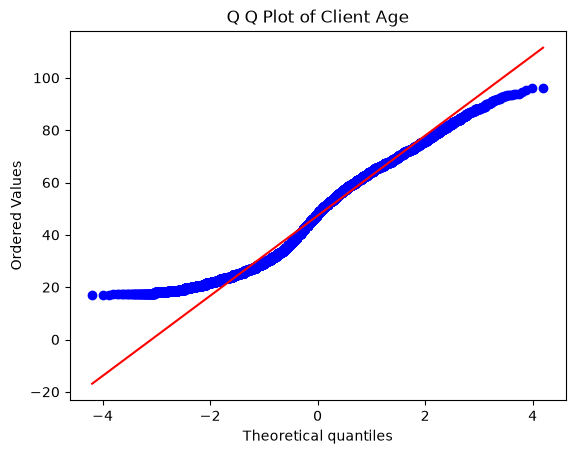

In [39]:
age_data = ab_clients_df["clnt_age"].dropna()

stats.probplot(
    age_data,
    dist="norm",
    plot=plt
)

plt.title("Q Q Plot of Client Age")
plt.show()

### Age Distribution Assessment

Client age has a skewness of 0.080, indicating that the distribution is approximately symmetric.

However, the kurtosis of -0.947 indicates a flatter distribution than the normal distribution. The Q Q plot also shows systematic departures from the theoretical normal reference line, particularly toward the tails.

Therefore, although client age is approximately symmetric, the distribution should not be considered normally distributed.

No age outliers were identified using the IQR method.


### Tenure

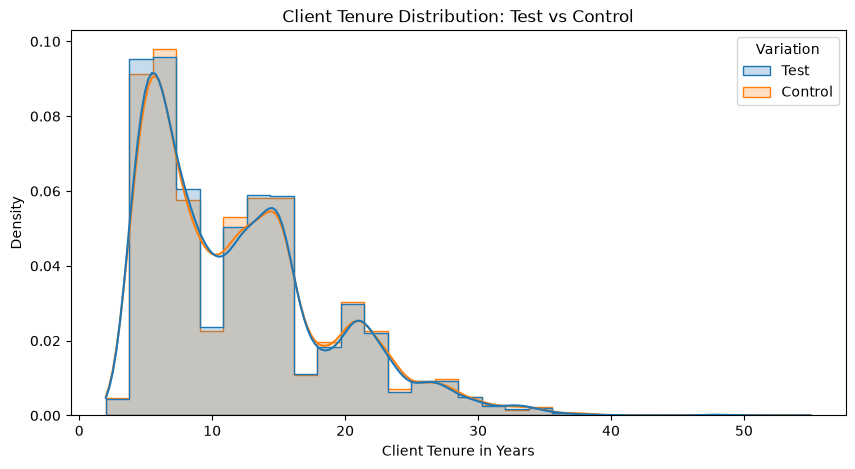

In [42]:

plt.figure(figsize=(10, 5))

sns.histplot(
    data=ab_clients_df,
    x="clnt_tenure_yr",
    hue="Variation",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Client Tenure Distribution: Test vs Control")
plt.xlabel("Client Tenure in Years")
plt.ylabel("Density")

plt.show()

### Client Tenure Distribution

The Test and Control groups show very similar client tenure distributions, with substantial overlap across nearly the entire range.

The Control group has an average tenure of approximately 12.09 years compared with 11.98 years for the Test group. Both groups have a median tenure of 11 years.

The tenure distribution is right skewed, with most clients concentrated at lower to moderate tenure levels and a smaller number of clients having substantially longer relationships with Vanguard.

Based on the descriptive statistics and visualization, there is no substantial difference in client tenure between the Test and Control groups.

In [44]:
#tenure outlier
q1_tenure = ab_clients_df["clnt_tenure_yr"].quantile(0.25)
q3_tenure = ab_clients_df["clnt_tenure_yr"].quantile(0.75)

iqr_tenure = q3_tenure - q1_tenure

lower_tenure = q1_tenure - 1.5 * iqr_tenure
upper_tenure = q3_tenure + 1.5 * iqr_tenure

print("Q1:", q1_tenure)
print("Q3:", q3_tenure)
print("IQR:", iqr_tenure)
print("Lower bound:", lower_tenure)
print("Upper bound:", upper_tenure)

Q1: 6.0
Q3: 16.0
IQR: 10.0
Lower bound: -9.0
Upper bound: 31.0


In [45]:
tenure_outliers = ab_clients_df[
    (ab_clients_df["clnt_tenure_yr"] < lower_tenure)
    | (ab_clients_df["clnt_tenure_yr"] > upper_tenure)
]

print("Tenure outliers:", len(tenure_outliers))

print(
    "Percentage:",
    round(
        len(tenure_outliers)
        / ab_clients_df["clnt_tenure_yr"].notna().sum()
        * 100,
        2
    ),
    "%"
)

Tenure outliers: 599
Percentage: 1.19 %


### Client Tenure Outlier Assessment

Using the IQR method, the lower tenure boundary was -9 years and the upper boundary was 31 years.

A total of 599 clients, approximately 1.19% of the experimental population with recorded tenure, were identified as statistical outliers above the upper boundary.

These observations will be retained. Long client tenure is plausible and the IQR method identifies unusual values rather than necessarily incorrect values. There is currently no evidence that these records represent data errors.

Therefore, tenure outliers are retained for the analysis.

In [47]:
tenure_outliers["Variation"].value_counts()

Variation
Test       325
Control    274
Name: count, dtype: int64

In [48]:
tenure_outlier_rates = (
    tenure_outliers["Variation"].value_counts()
    / ab_clients_df["Variation"].value_counts()
    * 100
)

tenure_outlier_rates

Variation
Test       1.205132
Control    1.164372
Name: count, dtype: float64

### Tenure Outliers by Experimental Group

The tenure outliers are similarly distributed between the experimental groups.

Approximately 1.21% of Test clients and 1.16% of Control clients were identified as tenure outliers using the IQR method.

The difference is very small, providing no descriptive evidence that unusually long tenure is concentrated in either experimental group.

The outliers will therefore be retained because they represent plausible long term client relationships and do not appear to create a meaningful imbalance between Test and Control.

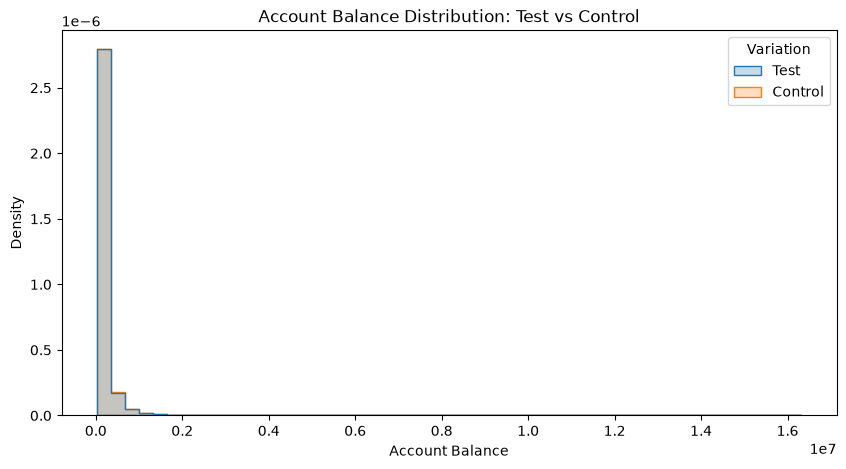

In [50]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=ab_clients_df,
    x="bal",
    hue="Variation",
    bins=50,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Account Balance Distribution: Test vs Control")
plt.xlabel("Account Balance")
plt.ylabel("Density")

plt.show()

### Account Balance Distribution

Account balance is strongly right skewed. Most clients are concentrated at substantially lower balance levels, while a relatively small number of clients have very high balances extending into the millions.

These high balance observations stretch the horizontal scale of the distribution and cause most observations to appear compressed toward the lower end.

The Control group has a mean balance of approximately $150,147 and a median balance of approximately $66,024. The Test group has a mean balance of approximately $148,963 and a median balance of approximately $65,468.

The large difference between the mean and median within both groups confirms that account balance is influenced by high value observations. Therefore, the median should be considered alongside the mean when comparing the experimental groups.

Despite the skewed distribution, the Test and Control groups show similar mean and median balances.

# Calculate specifically the 50,500 experimental clients, because of the Test versus Control concerns.

In [52]:

q1_balance = ab_clients_df["bal"].quantile(0.25)
q3_balance = ab_clients_df["bal"].quantile(0.75)

iqr_balance = q3_balance - q1_balance

lower_balance = q1_balance - 1.5 * iqr_balance
upper_balance = q3_balance + 1.5 * iqr_balance

print("Q1:", q1_balance)
print("Q3:", q3_balance)
print("IQR:", iqr_balance)
print("Lower bound:", lower_balance)
print("Upper bound:", upper_balance)

Q1: 39878.4075
Q3: 139956.54499999998
IQR: 100078.13749999998
Lower bound: -110238.79874999999
Upper bound: 290073.75125


In [53]:
balance_outliers = ab_clients_df[
    (ab_clients_df["bal"] < lower_balance)
    | (ab_clients_df["bal"] > upper_balance)
]

print("Balance outliers:", len(balance_outliers))

print(
    "Percentage:",
    round(
        len(balance_outliers)
        / ab_clients_df["bal"].notna().sum()
        * 100,
        2
    ),
    "%"
)

Balance outliers: 5728
Percentage: 11.35 %


In [54]:
balance_outlier_rates = (
    balance_outliers["Variation"].value_counts()
    / ab_clients_df["Variation"].value_counts()
    * 100
)

balance_outlier_rates

Variation
Test       11.146544
Control    11.567228
Name: count, dtype: float64

### Account Balance Outlier Assessment

Using the IQR method, account balances above approximately $290,074 were identified as statistical outliers.

A total of 5,728 experimental clients, approximately 11.35% of clients with recorded balances, were identified as balance outliers.

These observations will be retained. High account balances are plausible within an investment management context and should not automatically be treated as data errors. Removing them could also exclude an important high value client segment.

The outliers are similarly represented across the experimental groups. Approximately 11.15% of Test clients and 11.57% of Control clients were identified as balance outliers.

Therefore, there is no substantial descriptive evidence that high balance clients are disproportionately concentrated in either experimental group. Because the balance distribution is strongly right skewed, both median and mean balances will be considered when comparing the groups.

### Number of Accounts
Compare the number of accounts held by Test and Control clients.
# Number of accounts by experiment group

In [56]:


account_summary = (
    ab_clients_df
    .groupby("Variation")["num_accts"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

account_summary

,count,mean,median,std,min,max
Variation,,,,,,
Control,23527,2.259914,2.0,0.538559,2.0,7.0
Test,26961,2.249917,2.0,0.529335,1.0,7.0


 Compare number of accounts between Test and Control

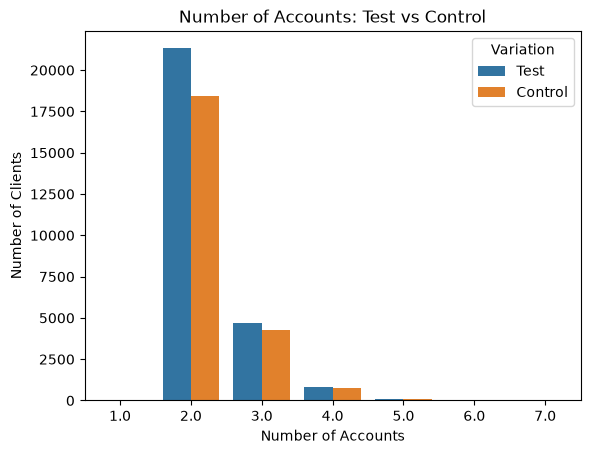

In [57]:


sns.countplot(
    data=ab_clients_df,
    x="num_accts",
    hue="Variation"
)

plt.title("Number of Accounts: Test vs Control")
plt.xlabel("Number of Accounts")
plt.ylabel("Number of Clients")

plt.show()

Percentage distribution of number of accounts by group

In [58]:


account_distribution = pd.crosstab(
    ab_clients_df["num_accts"],
    ab_clients_df["Variation"],
    normalize="columns"
) * 100

account_distribution.round(2)

Variation,Control,Test
num_accts,,
1.0,0.00,0.00
2.0,78.25,79.04
3.0,18.07,17.42
4.0,3.17,3.12
5.0,0.46,0.36
6.0,0.04,0.05
7.0,0.01,0.01


In [59]:
ab_clients_df[
    ab_clients_df["num_accts"] == 1
]["Variation"].value_counts()

Variation
Test    1
Name: count, dtype: int64

### Number of Accounts: Test vs Control

The number of accounts held by clients is very similar between the Test and Control groups.

The Control group has an average of approximately 2.26 accounts, while the Test group has an average of approximately 2.25 accounts. Both groups have a median of 2 accounts.

Approximately 78.25% of Control clients and 79.04% of Test clients hold 2 accounts. The proportions of clients holding 3, 4, 5, 6, or 7 accounts are also very similar between the groups.

Based on the descriptive statistics and percentage distributions, there is no meaningful imbalance in the number of accounts between Test and Control.

### Calls in the previous six months
whether one group historically contacted Vanguard more often before the experiment.

In [61]:

calls_summary = (
    ab_clients_df
    .groupby("Variation")["calls_6_mnth"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

calls_summary

,count,mean,median,std,min,max
Variation,,,,,,
Control,23527,3.129213,3.0,2.184502,0.0,6.0
Test,26961,3.061941,3.0,2.190590,0.0,6.0


In [62]:
calls_distribution = pd.crosstab(
    ab_clients_df["calls_6_mnth"],
    ab_clients_df["Variation"],
    normalize="columns"
) * 100

calls_distribution.round(2)

Variation,Control,Test
calls_6_mnth,,
0.0,14.84,15.73
1.0,15.27,16.01
2.0,14.67,13.96
3.0,11.41,11.75
4.0,9.61,9.59
5.0,9.57,9.11
6.0,24.63,23.85


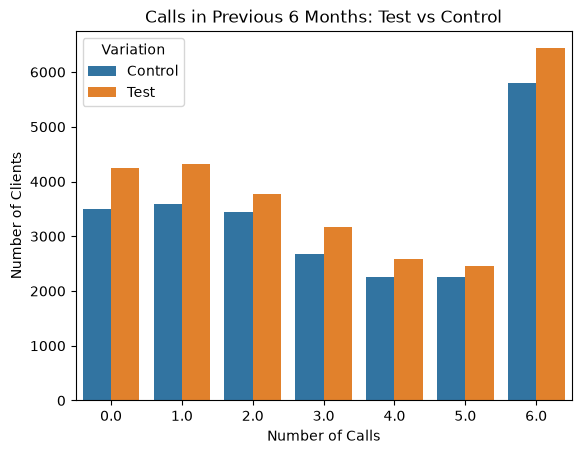

In [63]:
sns.countplot(
    data=ab_clients_df,
    x="calls_6_mnth",
    hue="Variation"
)

plt.title("Calls in Previous 6 Months: Test vs Control")
plt.xlabel("Number of Calls")
plt.ylabel("Number of Clients")

plt.show()

### Calls in the Previous Six Months

The historical call activity of Test and Control clients is very similar.

Control clients recorded an average of approximately 3.13 calls during the previous six months, while Test clients recorded approximately 3.06 calls. Both groups have a median of 3 calls.

The percentage distributions across the different call frequencies are also similar. No single call category shows a substantial difference between the groups.

Based on the descriptive statistics and percentage distributions, there is no meaningful evidence that one experimental group had substantially greater prior telephone engagement with Vanguard.

In [65]:
logons_summary = (
    ab_clients_df
    .groupby("Variation")["logons_6_mnth"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

logons_summary

,count,mean,median,std,min,max
Variation,,,,,,
Control,23527,6.166277,6.0,2.173014,3.0,9.0
Test,26961,6.101851,6.0,2.177119,3.0,9.0


# Percentage distribution

In [67]:

logons_distribution = pd.crosstab(
    ab_clients_df["logons_6_mnth"],
    ab_clients_df["Variation"],
    normalize="columns"
) * 100

logons_distribution.round(2)

Variation,Control,Test
logons_6_mnth,,
3.0,14.10,14.81
4.0,15.10,15.96
5.0,14.79,14.11
6.0,11.61,11.99
7.0,9.75,9.71
8.0,9.73,9.35
9.0,24.90,24.08


# Visualization

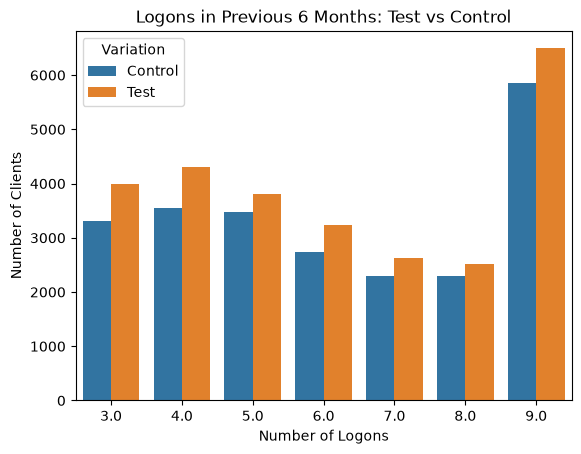

In [68]:

sns.countplot(
    data=ab_clients_df,
    x="logons_6_mnth",
    hue="Variation"
)

plt.title("Logons in Previous 6 Months: Test vs Control")
plt.xlabel("Number of Logons")
plt.ylabel("Number of Clients")

plt.show()

### Logons in the Previous Six Months

Prior digital engagement is very similar between the Test and Control groups.

Control clients recorded an average of approximately 6.17 logons during the previous six months, while Test clients recorded approximately 6.10 logons. Both groups have a median of 6 logons.

The percentage distributions across logon frequencies are also very similar. No single logon category shows a substantial difference between Test and Control.

Based on the descriptive statistics and percentage distributions, there is no meaningful evidence that one experimental group was substantially more digitally engaged before the A/B test.

### Statistical comparability
check the distribution and normality of clnt_age separately for Control and Test.
# Age distribution by experimental group

In [71]:


control_age = ab_clients_df[
    ab_clients_df["Variation"] == "Control"
]["clnt_age"].dropna()

test_age = ab_clients_df[
    ab_clients_df["Variation"] == "Test"
]["clnt_age"].dropna()

print("Control")
print(control_age.describe())

print("\nTest")
print(test_age.describe())

Control
count    23526.000000
mean        47.498427
std         15.521781
min         17.000000
25%         33.500000
50%         48.500000
75%         60.000000
max         96.000000
Name: clnt_age, dtype: float64

Test
count    26961.000000
mean        47.163922
std         15.514461
min         17.000000
25%         33.500000
50%         47.500000
75%         59.500000
max         96.000000
Name: clnt_age, dtype: float64


Control mean age is 47.50, while Test is 47.16, a difference of only about 0.33 years. Their standard deviations are almost identical, and their quartiles and ranges are also very similar.

# Age distribution and normality
Check the shape of the age distributions and assess whether normality is reasonable before selecting the hypothesis test.
# Check age distribution and normality

Control skewness: 0.063
Test skewness: 0.094


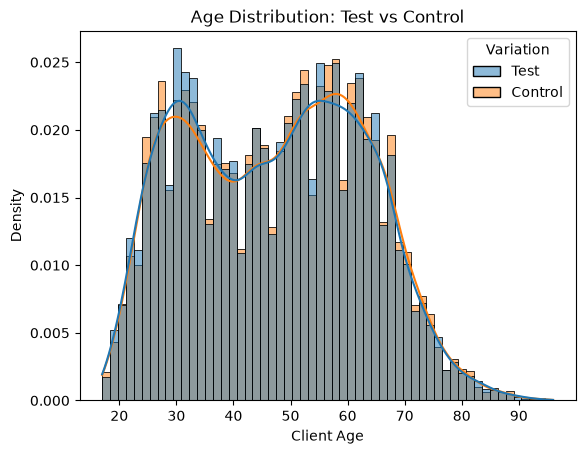

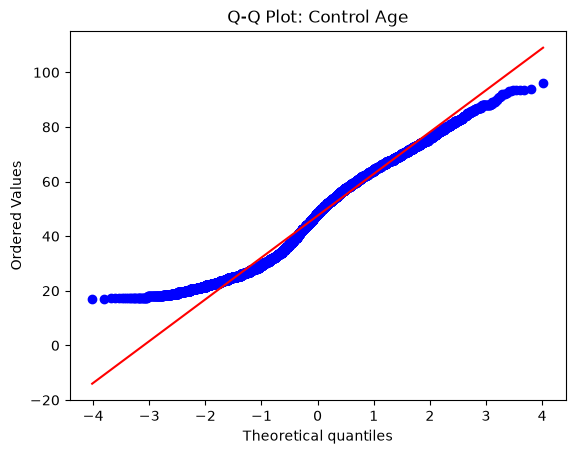

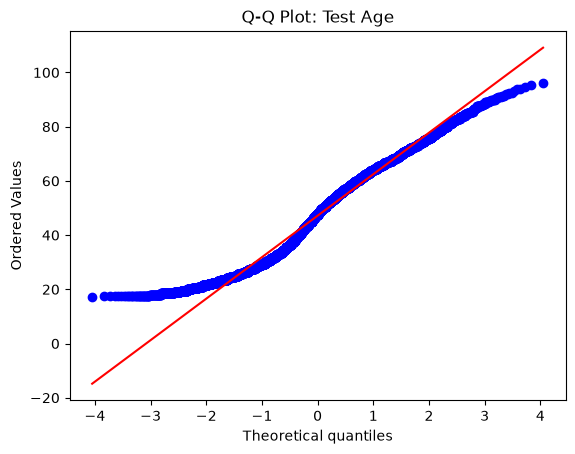

In [73]:


from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("Control skewness:", round(control_age.skew(), 3))
print("Test skewness:", round(test_age.skew(), 3))

# Histograms
sns.histplot(
    data=ab_clients_df,
    x="clnt_age",
    hue="Variation",
    stat="density",
    common_norm=False,
    kde=True
)

plt.title("Age Distribution: Test vs Control")
plt.xlabel("Client Age")
plt.ylabel("Density")
plt.show()

# Control Q-Q plot
stats.probplot(control_age, dist="norm", plot=plt)
plt.title("Q-Q Plot: Control Age")
plt.show()

# Test Q-Q plot
stats.probplot(test_age, dist="norm", plot=plt)
plt.title("Q-Q Plot: Test Age")
plt.show()

Both skewness values are extremely close to zero, so neither group shows meaningful overall skewness. However, the Q Q plots clearly deviate from the theoretical normal line, particularly in the tails. The histogram also shows that age is not perfectly normally distributed and has some structure rather than a classic bell shaped distribution.

Decision: Client age is not perfectly normally distributed, as shown by deviations from the theoretical line in the Q Q plots. However, both groups have very large sample sizes, low skewness, nearly identical variability, and strongly overlapping distributions. Therefore, comparison of mean age using an independent samples test is reasonable. Welch's independent samples t test will be used because it does not require equal population variances and provides a robust comparison of the two independent groups.

## Check variance equality
# Levene's test
Determine whether the variability in client age differs between Control and Test.
# Levene's test for equality of variances

In [75]:


levene_stat, levene_p = stats.levene(
    control_age,
    test_age
)

print("Levene statistic:", round(levene_stat, 4))
print("p-value:", round(levene_p, 4))

Levene statistic: 0.0414
p-value: 0.8388


Variance assumption: Levene's test produced a p value of 0.8388, which is greater than the 0.05 significance level. Therefore, we fail to reject the null hypothesis of equal variances. There is no evidence of a meaningful difference in age variability between the Control and Test groups.

# test the difference in mean age
two independent groups, very large samples, approximately symmetric distributions, and no evidence of unequal variance, an independent samples t test is appropriate.
# Independent samples t-test for client age

In [77]:


t_stat, p_value = stats.ttest_ind(
    control_age,
    test_age,
    equal_var=True
)

print("t-statistic:", round(t_stat, 4))
print("p-value:", round(p_value, 4))

t-statistic: 2.4161
p-value: 0.0157


There is statistical evidence that the mean age differs between the Control and Test groups.

# Cohen's d
Measure how large the age difference actually is relative to the variability in customer age.
# Cohen's d for client age


In [79]:

mean_difference = control_age.mean() - test_age.mean()

pooled_std = (
    (
        (len(control_age) - 1) * control_age.var()
        + (len(test_age) - 1) * test_age.var()
    )
    / (len(control_age) + len(test_age) - 2)
) ** 0.5

cohens_d = mean_difference / pooled_std

print("Mean difference:", round(mean_difference, 4))
print("Cohen's d:", round(cohens_d, 4))

Mean difference: 0.3345
Cohen's d: 0.0216


Interpretation: The independent samples t test found a statistically significant difference in mean client age between the Control and Test groups, with t = 2.4161 and p = 0.0157. However, the mean difference was only 0.3345 years and Cohen's d was 0.0216, indicating a negligible effect size. Therefore, the age difference is statistically detectable because of the large sample size but is not practically meaningful. Client age does not appear to represent a material threat to the comparability of the experimental groups.

# Critical value visualization
Satisfy the requirement to show the LCV, UCV, rejection regions, test statistic and alpha.
# Critical value visualization for client age

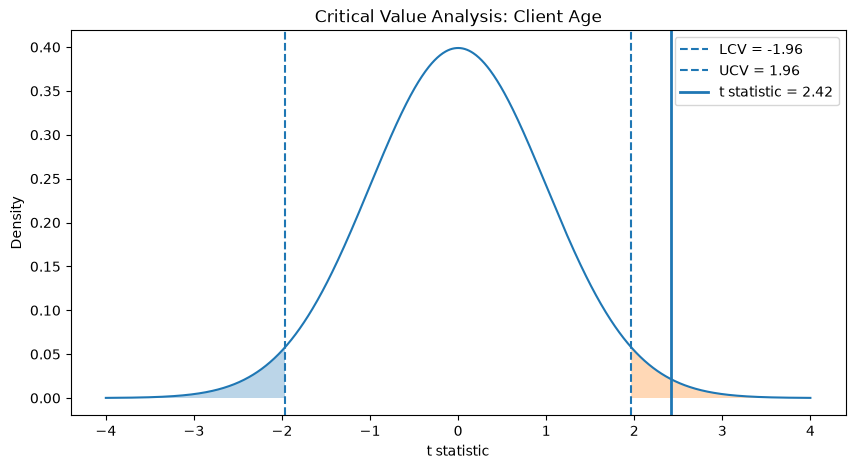

Alpha: 0.05
LCV: -1.96
UCV: 1.96
Test statistic: 2.4161
p-value: 0.0157
Decision: Reject H0


In [81]:


import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

alpha = 0.05

df_t = len(control_age) + len(test_age) - 2

lcv = stats.t.ppf(alpha / 2, df_t)
ucv = stats.t.ppf(1 - alpha / 2, df_t)

x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df_t)

plt.figure(figsize=(10, 5))

plt.plot(x, y)

# Rejection regions
plt.fill_between(
    x,
    0,
    y,
    where=(x <= lcv),
    alpha=0.3
)

plt.fill_between(
    x,
    0,
    y,
    where=(x >= ucv),
    alpha=0.3
)

# Critical values
plt.axvline(
    lcv,
    linestyle="--",
    label=f"LCV = {lcv:.2f}"
)

plt.axvline(
    ucv,
    linestyle="--",
    label=f"UCV = {ucv:.2f}"
)

# Test statistic
plt.axvline(
    t_stat,
    linewidth=2,
    label=f"t statistic = {t_stat:.2f}"
)

plt.title("Critical Value Analysis: Client Age")
plt.xlabel("t statistic")
plt.ylabel("Density")

plt.legend()
plt.show()

print("Alpha:", alpha)
print("LCV:", round(lcv, 4))
print("UCV:", round(ucv, 4))
print("Test statistic:", round(t_stat, 4))
print("p-value:", round(p_value, 4))

if t_stat < lcv or t_stat > ucv:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")

Decision and business interpretation: At α = 0.05, the test statistic of 2.4161 exceeds the upper critical value of 1.96. The p value of 0.0157 is also below α. Therefore, the null hypothesis is rejected, providing statistical evidence of a difference in mean client age between the Control and Test groups.

However, the difference is only 0.3345 years and Cohen's d is 0.0216, indicating a negligible effect size. The distributions also show substantial overlap and nearly identical variability. The statistically significant result is therefore likely driven by the very large sample size rather than a meaningful difference between the groups.

Decision: Client age does not represent a practically meaningful imbalance and is unlikely to make the experimental comparison unfair.

### Gender
Determine whether the gender distribution differs between the Control and Test groups.
# Gender contingency table

In [83]:


gender_table = pd.crosstab(
    ab_clients_df["gendr"],
    ab_clients_df["Variation"]
)

gender_table

Variation,Control,Test
gendr,,
F,7543,8716
M,7970,8977
U,8014,9266
X,0,2


# Check Chi square assumptions

# Check expected frequencies for gender

In [84]:


from scipy import stats

chi2, p_value, dof, expected = stats.chi2_contingency(
    gender_table
)

expected_df = pd.DataFrame(
    expected,
    index=gender_table.index,
    columns=gender_table.columns
)

expected_df.round(2)

Variation,Control,Test
gendr,,
F,7576.56,8682.44
M,7897.17,9049.83
U,8052.34,9227.66
X,0.93,1.07


In [85]:
# Check cells with expected frequency below 5

print(
    "Cells with expected frequency below 5:",
    (expected_df < 5).sum().sum()
)

print(
    "Minimum expected frequency:",
    round(expected_df.min().min(), 2)
)

Cells with expected frequency below 5: 2
Minimum expected frequency: 0.93


Gender test assumption: The original gender variable contains the categories F, M, U and X. The X category contains only two experimental clients, producing expected Chi square frequencies of 0.93 and 1.07. Because these values are below the commonly used minimum expected frequency of 5, the full contingency table does not adequately satisfy the Chi square assumption.

The X category will therefore be excluded only from the statistical gender comparability test. The two records will remain unchanged in the underlying dataset. X will not be combined with another category because its meaning is not defined in the source data.

# Comparison using only F, M, and U
# Gender table for Chi-square test

In [86]:


gender_test_df = ab_clients_df[
    ab_clients_df["gendr"].isin(["F", "M", "U"])
]

gender_test_table = pd.crosstab(
    gender_test_df["gendr"],
    gender_test_df["Variation"]
)

gender_test_table

Variation,Control,Test
gendr,,
F,7543,8716
M,7970,8977
U,8014,9266


In [87]:
#expected frequencies
chi2_gender, p_gender, dof_gender, expected_gender = (
    stats.chi2_contingency(gender_test_table)
)

expected_gender_df = pd.DataFrame(
    expected_gender,
    index=gender_test_table.index,
    columns=gender_test_table.columns
)

expected_gender_df.round(2)

Variation,Control,Test
gendr,,
F,7576.86,8682.14
M,7897.48,9049.52
U,8052.66,9227.34


In [88]:
#minimum expected frequency
print(
    "Minimum expected frequency:",
    round(expected_gender_df.min().min(), 2)
)

Minimum expected frequency: 7576.86


Assumption check: After excluding the two observations coded as X from the statistical test, all expected frequencies are well above 5. The minimum expected frequency is 7,576.86. Therefore, the expected frequency assumption for the Chi square test is satisfied, and the test can be used to evaluate whether gender distribution differs between the Control and Test groups.

# Chi square test

In [90]:

chi2_gender, p_gender, dof_gender, expected_gender = (
    stats.chi2_contingency(gender_test_table)
)
print("Chi-square statistic:", round(chi2_gender, 4))
print("Degrees of freedom:", dof_gender)
print("p-value:", round(p_gender, 4))
print("Alpha:", 0.05)

Chi-square statistic: 1.8781
Degrees of freedom: 2
p-value: 0.391
Alpha: 0.05


Interpretation: The Chi square test produced χ² = 1.8781 with 2 degrees of freedom and p = 0.391. Since the p value is greater than the significance level of 0.05, we fail to reject the null hypothesis. There is no statistically significant evidence that gender distribution differs between the Control and Test groups. Gender therefore does not appear to create an imbalance between the experimental groups.

# Cramér's V

In [92]:

#Measure the strength of the association between gender and experimental group.
n = gender_test_table.to_numpy().sum()

cramers_v_gender = np.sqrt(
    chi2_gender / (n * min(gender_test_table.shape[0] - 1,
                           gender_test_table.shape[1] - 1))
)

print("Cramér's V:", round(cramers_v_gender, 4))

Cramér's V: 0.0061


Effect size: Cramér's V = 0.0061, indicating a negligible association between gender and experimental group.

Decision: At α = 0.05, we fail to reject H0 because p = 0.391. There is no statistically significant difference in gender distribution between the Control and Test groups.

Business interpretation: The negligible effect size confirms that the gender distributions are practically equivalent for the purpose of this experiment. Gender is therefore unlikely to bias later comparisons of website performance between the two groups.

Analytical decision: Gender does not present a meaningful threat to experimental comparability. The Control and Test groups can be considered well balanced with respect to gender.

# Tenure comparability
compare the Control and Test tenure to examine the centre, spread, and range of client tenure in each experimental group before selecting the statistical test.

In [94]:

control_tenure = ab_clients_df[
    ab_clients_df["Variation"] == "Control"
]["clnt_tenure_yr"].dropna()

test_tenure = ab_clients_df[
    ab_clients_df["Variation"] == "Test"
]["clnt_tenure_yr"].dropna()

print("Control")
print(control_tenure.describe())

print("\nTest")
print(test_tenure.describe())

Control
count    23527.000000
mean        12.087686
std          6.877531
min          2.000000
25%          6.000000
50%         11.000000
75%         16.000000
max         55.000000
Name: clnt_tenure_yr, dtype: float64

Test
count    26961.000000
mean        11.982901
std          6.844947
min          2.000000
25%          6.000000
50%         11.000000
75%         15.000000
max         55.000000
Name: clnt_tenure_yr, dtype: float64


Control mean is 12.09 years and Test mean is 11.98 years, a difference of only about 0.10 year. Both groups have the same median of 11 years, the same minimum of 2 and maximum of 55, and almost identical standard deviations.

# Tenure distribution
Determine whether client tenure is approximately normally distributed and whether a parametric comparison is appropriate.

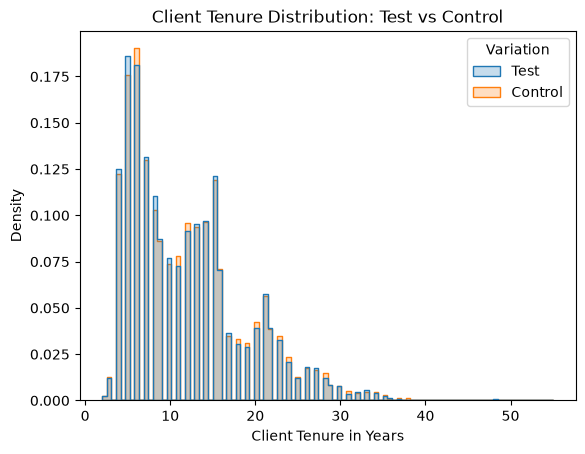

In [95]:

sns.histplot(
    data=ab_clients_df,
    x="clnt_tenure_yr",
    hue="Variation",
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Client Tenure Distribution: Test vs Control")
plt.xlabel("Client Tenure in Years")
plt.ylabel("Density")
plt.show()

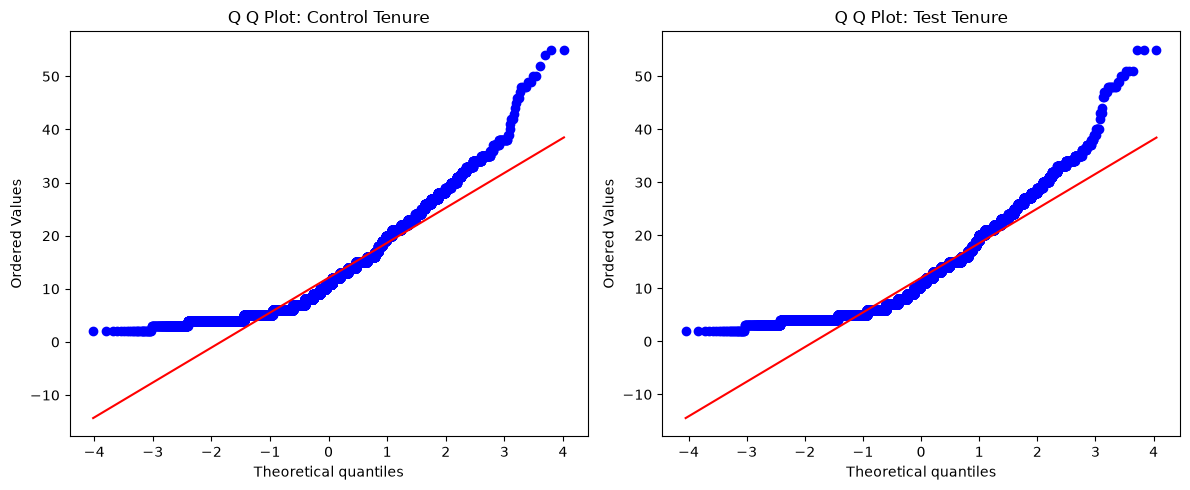

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(
    control_tenure,
    dist="norm",
    plot=axes[0]
)
axes[0].set_title("Q Q Plot: Control Tenure")

stats.probplot(
    test_tenure,
    dist="norm",
    plot=axes[1]
)
axes[1].set_title("Q Q Plot: Test Tenure")

plt.tight_layout()
plt.show()

### Tenure Distribution Assessment

The Q Q plots show clear deviations from the theoretical normal distribution for both the Control and Test groups, particularly in the lower and upper tails. Therefore, client tenure should not be considered normally distributed.

Importantly, the two groups display very similar distributional shapes. The descriptive statistics also show nearly identical centres and spreads, with median tenure of 11 years in both groups and mean tenure of approximately 12 years.

The high tenure observations are retained because they represent plausible long term customers rather than confirmed data errors.

Decision: Because the normality assumption is not well supported, a nonparametric Mann Whitney U test will be used to compare the tenure distributions between the independent Control and Test groups.

In [98]:
#Mann Whitney U test
u_stat, p_value = stats.mannwhitneyu(
    control_tenure,
    test_tenure,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", round(u_stat, 2))
print("p-value:", round(p_value, 4))
print("Alpha:", 0.05)

Mann-Whitney U statistic: 319947226.0
p-value: 0.0869
Alpha: 0.05


### Mann Whitney U Test Interpretation

The Mann Whitney U test returned a p value of 0.0869, which is greater than the significance level of 0.05.

Therefore, we fail to reject the null hypothesis. There is insufficient statistical evidence to conclude that client tenure differs between the Control and Test groups.

This result is consistent with the descriptive statistics. The median tenure is 11 years in both groups, while the mean tenure is approximately 12.09 years for Control and 11.98 years for Test.

Business interpretation: Client tenure does not appear to create a meaningful imbalance between the experimental groups. Therefore, tenure is unlikely to bias the later comparison of website performance between Control and Test.

In [119]:
u_stat_tenure = 319947226.0

n_control = len(control_tenure)
n_test = len(test_tenure)

mean_u = n_control * n_test / 2

std_u = (
    n_control
    * n_test
    * (n_control + n_test + 1)
    / 12
) ** 0.5

z_tenure = (u_stat_tenure - mean_u) / std_u

n_total = n_control + n_test

r_tenure = abs(z_tenure) / (n_total ** 0.5)

print("Z statistic:", round(z_tenure, 4))
print("Effect size r:", round(r_tenure, 4))

Z statistic: 1.7088
Effect size r: 0.0076


### Interpretation

The Mann Whitney U test produced a p value of **0.0869**, which is greater than the alpha level of **0.05**. Therefore, we fail to reject the null hypothesis. There is insufficient statistical evidence of a difference in client tenure between the Control and Test groups.

The effect size was **r = 0.0076**, indicating a negligible difference between the groups.

The descriptive statistics support this result. Both groups had a median tenure of **11 years**, while the mean tenure was approximately **12.09 years for Control** and **11.98 years for Test**.

Statistical decision: Fail to reject H0.

Effect size: Negligible.

Business interpretation:** Client tenure does not represent a meaningful baseline imbalance between the Control and Test groups and is unlikely to affect the fairness of the experiment.

### Number of Accounts

### Statistical Test: Number of Accounts

H0:The distribution of the number of accounts is the same between the Control and Test groups.
H1: The distribution of the number of accounts differs between the Control and Test groups.
Alpha:0.05

The number of accounts is a discrete count variable and is strongly concentrated around two accounts. Because the distribution is not continuous and normally distributed, the Mann Whitney U test is used to compare the two independent experimental groups.

In [100]:
#Mann Whitney U test
control_accounts = ab_clients_df[
    ab_clients_df["Variation"] == "Control"
]["num_accts"].dropna()

test_accounts = ab_clients_df[
    ab_clients_df["Variation"] == "Test"
]["num_accts"].dropna()

u_stat_accounts, p_value_accounts = stats.mannwhitneyu(
    control_accounts,
    test_accounts,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", round(u_stat_accounts, 4))
print("p-value:", round(p_value_accounts, 4))
print("Alpha:", 0.05)

Mann-Whitney U statistic: 319678277.0
p-value: 0.0302
Alpha: 0.05


In [101]:
alpha = 0.05

if p_value_accounts < alpha:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")

Decision: Reject H0


### Interpretation

The Mann Whitney U test produced a p value of 0.0302, which is below the alpha level of 0.05. Therefore, the null hypothesis is rejected, indicating a statistically significant difference in the distribution of the number of accounts between the Control and Test groups.

However, the descriptive difference is very small. The Control group has an average of approximately 2.26 accounts compared with 2.25 accounts in the Test group, while both groups have a median of 2 accounts.

Therefore, although the difference is statistically significant, the observed difference appears small from a practical perspective. An effect size should be calculated before determining whether this difference represents a meaningful baseline imbalance.

# Effect Size

In [102]:

n_control = len(control_accounts)
n_test = len(test_accounts)

mean_u = n_control * n_test / 2

std_u = (
    n_control
    * n_test
    * (n_control + n_test + 1)
    / 12
) ** 0.5

z_accounts = (u_stat_accounts - mean_u) / std_u

n_total = n_control + n_test

r_accounts = abs(z_accounts) / (n_total ** 0.5)

print("Z statistic:", round(z_accounts, 4))
print("Effect size r:", round(r_accounts, 4))

Z statistic: 1.5441
Effect size r: 0.0069


### Effect Size and Practical Significance

The Mann Whitney U test found a statistically significant difference in the number of accounts between the Control and Test groups, with a p value of 0.0302.

However, the effect size is only **r = 0.0069**, indicating a negligible difference between the groups.

This is consistent with the descriptive statistics. The Control group has an average of approximately 2.26 accounts and the Test group approximately 2.25 accounts, while both groups have a median of 2 accounts.

Statistical decision:Reject H0.

Practical decision:** The difference is too small to represent a meaningful baseline imbalance.

Business interpretation:** The statistically significant result is likely influenced by the large sample size rather than an important difference in customer characteristics. Number of accounts is therefore not considered a material threat to the comparability of the Control and Test groups.

### Account Balance Statistical Test

H0:The distribution of account balances is the same between the Control and Test groups.

H1:The distribution of account balances differs between the Control and Test groups.

Alpha: 0.05

Account balance is a continuous financial variable with a strongly right skewed distribution and substantial high value observations. Because the distribution does not satisfy the normality assumption required for a standard independent samples t test, the Mann Whitney U test is used to compare the two independent experimental groups.

The original balance observations are retained because unusually high balances may represent genuine customer characteristics rather than data errors.

# Mann Whitney U

In [104]:

control_balance = ab_clients_df[
    ab_clients_df["Variation"] == "Control"
]["bal"].dropna()

test_balance = ab_clients_df[
    ab_clients_df["Variation"] == "Test"
]["bal"].dropna()

u_stat_balance, p_value_balance = stats.mannwhitneyu(
    control_balance,
    test_balance,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", round(u_stat_balance, 4))
print("p-value:", round(p_value_balance, 4))
print("Alpha:", 0.05)

Mann-Whitney U statistic: 319515677.0
p-value: 0.1486
Alpha: 0.05


In [105]:
alpha = 0.05

if p_value_balance < alpha:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")

Decision: Fail to reject H0


### Statistical Interpretation

The Mann Whitney U test produced a p value of **0.1486**, which is greater than the alpha level of **0.05**.

Therefore, we **fail to reject the null hypothesis**.

There is insufficient statistical evidence to conclude that the distribution of account balances differs between the Control and Test groups.

This result is consistent with the descriptive analysis, which showed similar balance distributions between the two groups despite the strong right skew and high value observations.

Statistical decision:Fail to reject H0.

Business interpretation: No statistically significant baseline imbalance in account balance was identified. Account balance therefore does not currently appear to threaten the comparability of the Control and Test groups.

# Effect size

In [107]:

n_control = len(control_balance)
n_test = len(test_balance)

mean_u = n_control * n_test / 2

std_u = (
    n_control
    * n_test
    * (n_control + n_test + 1)
    / 12
) ** 0.5

z_balance = (u_stat_balance - mean_u) / std_u

n_total = n_control + n_test

r_balance = abs(z_balance) / (n_total ** 0.5)

print("Z statistic:", round(z_balance, 4))
print("Effect size r:", round(r_balance, 4))

Z statistic: 1.4446
Effect size r: 0.0064


### Effect Size and Practical Significance

The Mann Whitney U test found no statistically significant difference in account balance between the Control and Test groups, with a p value of **0.1486**.

The effect size is **r = 0.0064**, indicating a negligible difference between the groups.

This supports the descriptive findings. Although account balances are strongly right skewed and contain high value observations, the Control and Test groups show very similar overall balance characteristics.

Statistical decision: Fail to reject H0.

Effect size: Negligible.

Practical decision: No meaningful baseline difference was identified.

Business interpretation: Account balance does not appear to represent a material imbalance between the experimental groups and is unlikely to threaten the fairness of later A/B test comparisons.

### Calls in Previous 6 Months
### Statistical Test: Calls in Previous 6 Months

H0: The distribution of calls in the previous six months is the same between the Control and Test groups.

H1: The distribution of calls in the previous six months differs between the Control and Test groups.

Alpha: 0.05

Calls in the previous six months is a discrete count variable. The Mann Whitney U test is used to compare the distributions between the two independent experimental groups without requiring a normal distribution.

In [109]:
control_calls = ab_clients_df[
    ab_clients_df["Variation"] == "Control"
]["calls_6_mnth"].dropna()

test_calls = ab_clients_df[
    ab_clients_df["Variation"] == "Test"
]["calls_6_mnth"].dropna()

u_stat_calls, p_value_calls = stats.mannwhitneyu(
    control_calls,
    test_calls,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", round(u_stat_calls, 4))
print("p-value:", round(p_value_calls, 4))
print("Alpha:", 0.05)

if p_value_calls < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")

Mann-Whitney U statistic: 322761260.5
p-value: 0.0005
Alpha: 0.05
Decision: Reject H0


Since 0.0005 < 0.05, there is statistical evidence that the distribution of calls differs between Control and Test.

# Effect Size

In [110]:

n_control = len(control_calls)
n_test = len(test_calls)

mean_u = n_control * n_test / 2

std_u = (
    n_control
    * n_test
    * (n_control + n_test + 1)
    / 12
) ** 0.5

z_calls = (u_stat_calls - mean_u) / std_u

n_total = n_control + n_test

r_calls = abs(z_calls) / (n_total ** 0.5)

print("Z statistic:", round(z_calls, 4))
print("Effect size r:", round(r_calls, 4))

Z statistic: 3.4313
Effect size r: 0.0153


# Logons in Previous 6 Months
### Statistical Test: Logons in Previous 6 Months

H0: The distribution of logons in the previous six months is the same between the Control and Test groups.

H1: The distribution of logons in the previous six months differs between the Control and Test groups.

Alpha: 0.05

Logons in the previous six months is a discrete count variable. The Mann Whitney U test is used to compare the distributions between the two independent experimental groups without requiring a normal distribution.

In [112]:
control_logons = ab_clients_df[
    ab_clients_df["Variation"] == "Control"
]["logons_6_mnth"].dropna()

test_logons = ab_clients_df[
    ab_clients_df["Variation"] == "Test"
]["logons_6_mnth"].dropna()

u_stat_logons, p_value_logons = stats.mannwhitneyu(
    control_logons,
    test_logons,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", round(u_stat_logons, 4))
print("p-value:", round(p_value_logons, 4))
print("Alpha:", 0.05)

if p_value_logons < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")

Mann-Whitney U statistic: 322535815.0
p-value: 0.0008
Alpha: 0.05
Decision: Reject H0


Since 0.0008 < 0.05, there is statistical evidence that the distribution of logons differs between Control and Test.

# Effect size

In [114]:

n_control = len(control_logons)
n_test = len(test_logons)

mean_u = n_control * n_test / 2

std_u = (
    n_control
    * n_test
    * (n_control + n_test + 1)
    / 12
) ** 0.5

z_logons = (u_stat_logons - mean_u) / std_u

n_total = n_control + n_test

r_logons = abs(z_logons) / (n_total ** 0.5)

print("Z statistic:", round(z_logons, 4))
print("Effect size r:", round(r_logons, 4))

Z statistic: 3.2933
Effect size r: 0.0147


### Effect Size and Practical Significance

The Mann Whitney U test produced a p value of **0.0008**, which is below the alpha level of **0.05**. Therefore, the null hypothesis is rejected, indicating a statistically significant difference in the distribution of logons between the Control and Test groups.

However, the effect size is only **r = 0.0147**, indicating a negligible difference.

This is consistent with the descriptive statistics. The Control group averaged approximately 6.17 logons and the Test group approximately 6.10 logons, while both groups had a median of 6 logons.

statistical decision:Reject H0.

Effect size:Negligible.

Practical decision: The observed difference is too small to represent a meaningful baseline imbalance.

Business interpretation:Although historical digital engagement differs statistically between the groups, the magnitude of the difference is negligible. Logon activity is therefore not considered a material threat to the comparability of the Control and Test groups.

# Day 2 Statistical Summary
| Variable           | Test                       | p value | Decision          | Effect size | Practical significance |
| ------------------ | -------------------------- | ------: | ----------------- | ----------: | ---------------------- |
| Age                | Independent samples t test |  0.0157 | Reject H0         |  d = 0.0216 | Negligible             |
| Gender             | Chi square                 |  0.3910 | Fail to reject H0 |  V = 0.0061 | Negligible             |
| Tenure             | Mann Whitney U             |  0.0869 | Fail to reject H0 |  r = 0.0076 | Negligible             |
| Number of accounts | Mann Whitney U             |  0.0302 | Reject H0         |  r = 0.0069 | Negligible             |
| Balance            | Mann Whitney U             |  0.1486 | Fail to reject H0 |  r = 0.0064 | Negligible             |
| Calls              | Mann Whitney U             |  0.0005 | Reject H0         |  r = 0.0153 | Negligible             |
| Logons             | Mann Whitney U             |  0.0008 | Reject H0         |  r = 0.0147 | Negligible             |



## Conclusion

The purpose of this analysis was to determine whether the Control and Test groups were sufficiently comparable before evaluating the performance of Vanguard's new digital experience.

The demographic, financial and digital engagement characteristics of the two groups were examined using descriptive statistics, distribution comparisons and appropriate statistical tests.

Some statistically significant differences were identified. Age, number of accounts, calls and logons produced p values below the 0.05 significance level. However, the corresponding effect sizes were negligible. Age had a Cohen's d of 0.0216, while the effect sizes for number of accounts, calls and logons were all below 0.02.

Gender, client tenure and account balance did not show statistically significant differences between the Control and Test groups. Their effect sizes were also negligible.

These findings demonstrate the importance of distinguishing statistical significance from practical significance. With a large sample, very small differences can produce statistically significant results even when the magnitude of those differences is too small to be meaningful.

### Final Decision

The Control and Test groups are considered **sufficiently comparable for the A/B test analysis**.

No substantial demographic, financial or historical engagement imbalance was identified that would make the comparison materially unfair. The statistically significant differences observed in several variables have negligible effect sizes and therefore do not represent meaningful threats to the validity of the experiment.

The analysis can proceed to customer journey and KPI evaluation. The small baseline differences should still be acknowledged when interpreting subsequent results, but based on the evidence examined in Day 2, there is no indication that they are large enough to materially bias the comparison between the Control and Test groups.